In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the data
df = pd.read_csv('framingham.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Variable Distribution:")
print(df['TenYearCHD'].value_counts())
print("\nPercentage of CHD cases:", df['TenYearCHD'].mean() * 100)

Dataset Shape: (4238, 16)

First few rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenY

In [3]:
# Data Preprocessing
def preprocess_data(df):
    # Create a copy to avoid modifying original data
    data = df.copy()
    
    # Handle missing values - use median for numerical, mode for categorical
    numerical_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
    categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
    
    # Impute numerical columns with median
    for col in numerical_cols:
        if col in data.columns:
            data[col].fillna(data[col].median(), inplace=True)
    
    # Impute categorical columns with mode
    for col in categorical_cols:
        if col in data.columns:
            data[col].fillna(data[col].mode()[0], inplace=True)
    
    return data

# Preprocess the data
df_processed = preprocess_data(df)

# Feature Engineering
def create_features(df):
    data = df.copy()
    
    # Create BMI categories
    data['BMI_category'] = pd.cut(data['BMI'], 
                                bins=[0, 18.5, 25, 30, 100], 
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    
    # Create age groups
    data['age_group'] = pd.cut(data['age'], 
                             bins=[0, 40, 50, 60, 100], 
                             labels=['Young', 'Middle', 'Senior', 'Elderly'])
    
    # Create blood pressure risk
    data['BP_risk'] = np.where((data['sysBP'] >= 140) | (data['diaBP'] >= 90), 1, 0)
    
    # Create total cardiovascular risk score (simplified)
    data['risk_score'] = (data['age'] / 10 + 
                         data['cigsPerDay'] / 10 + 
                         data['sysBP'] / 100 + 
                         data['totChol'] / 200 + 
                         data['prevalentHyp'] * 2 + 
                         data['diabetes'] * 3)
    
    return data

df_features = create_features(df_processed)

# Prepare features and target
# Select features for modeling
feature_columns = ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 
                  'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 
                  'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
                  'BP_risk', 'risk_score']

X = df_features[feature_columns]
y = df_features['TenYearCHD']

print("Feature matrix shape:", X.shape)
print("Target variable distribution:")
print(y.value_counts())

Feature matrix shape: (4238, 17)
Target variable distribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Positive cases in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Positive cases in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

# Define models with pipelines
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LogisticRegression(random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='median')),
        ('model', SVC(random_state=42, class_weight='balanced', probability=True))
    ])
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = model.score(X_test, y_test)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, AUC: {auc_score:.4f}")

# Find best model based on AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']
print(f"\nBest Model: {best_model_name} with AUC: {results[best_model_name]['auc']:.4f}")

Training set size: (3390, 17)
Test set size: (848, 17)
Positive cases in training: 515 (15.19%)
Positive cases in test: 129 (15.21%)

Training Logistic Regression...
Logistic Regression - Accuracy: 0.6698, AUC: 0.6985

Training Random Forest...
Random Forest - Accuracy: 0.8479, AUC: 0.6389

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.8396, AUC: 0.6572

Training SVM...
SVM - Accuracy: 0.6722, AUC: 0.6779

Best Model: Logistic Regression with AUC: 0.6985



=== Detailed Analysis for Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       719
           1       0.25      0.58      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.63      0.56       848
weighted avg       0.80      0.67      0.71       848



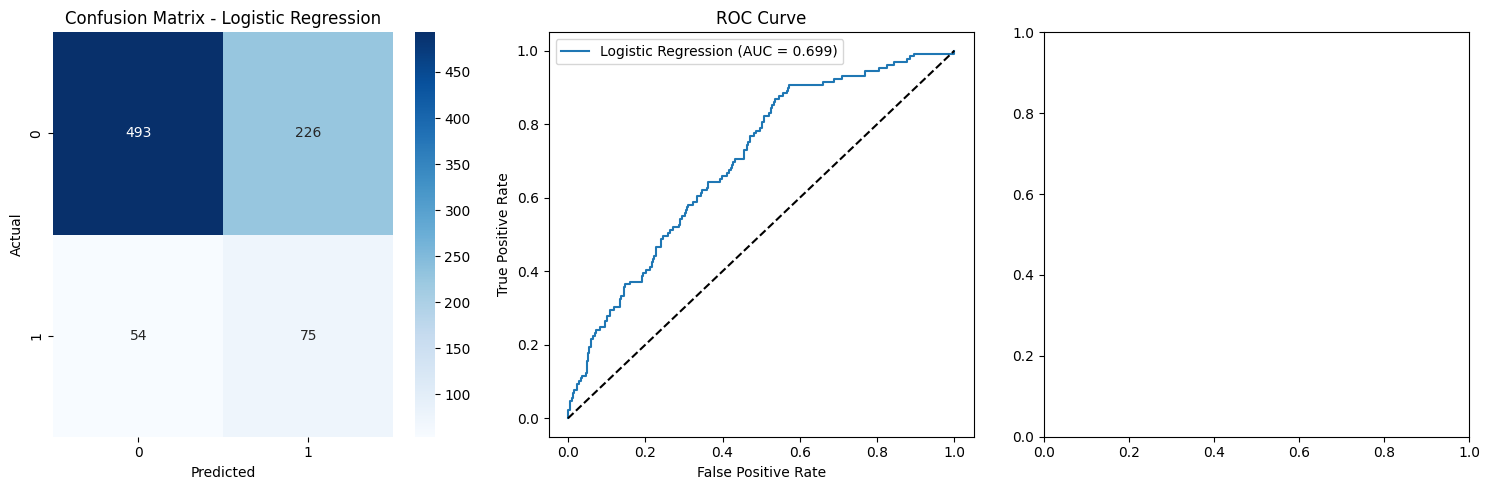

In [5]:
# Detailed analysis with the best model
best_result = results[best_model_name]

print(f"\n=== Detailed Analysis for {best_model_name} ===")
print("\nClassification Report:")
print(classification_report(y_test, best_result['predictions']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['predictions'])
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, best_result['probabilities'])
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {best_result["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Feature Importance (if available)
plt.subplot(1, 3, 3)
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feature_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': importances
    }).sort_values('importance', ascending=True)
    
    plt.barh(feature_imp['feature'], feature_imp['importance'])
    plt.title('Feature Importance')
    plt.xlabel('Importance')

plt.tight_layout()
plt.show()

In [6]:
# Hyperparameter tuning for the best model
if best_model_name == 'Random Forest':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.15],
        'model__max_depth': [3, 4, 5]
    }
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'model__C': [0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    }
else:  # SVM
    param_grid = {
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto']
    }

print(f"\nPerforming Grid Search for {best_model_name}...")
grid_search = GridSearchCV(
    best_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Evaluate tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

tuned_accuracy = tuned_model.score(X_test, y_test)
tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\nTuned Model Performance:")
print(f"Accuracy: {tuned_accuracy:.4f}")
print(f"AUC: {tuned_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Performing Grid Search for Logistic Regression...
Best parameters: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best cross-validation AUC: 0.7323

Tuned Model Performance:
Accuracy: 0.6639
AUC: 0.6999

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       719
           1       0.25      0.60      0.35       129

    accuracy                           0.66       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.66      0.71       848



In [7]:
# Risk prediction function
def predict_chd_risk(model, patient_data, feature_names=feature_columns):
    """
    Predict CHD risk for a new patient
    """
    # Ensure patient data has the right format
    if isinstance(patient_data, dict):
        patient_df = pd.DataFrame([patient_data])
    else:
        patient_df = patient_data.copy()
    
    # Make sure all features are present
    for feature in feature_names:
        if feature not in patient_df.columns:
            patient_df[feature] = 0  # or use appropriate default
    
    # Reorder columns to match training
    patient_df = patient_df[feature_names]
    
    # Predict probability
    risk_probability = model.predict_proba(patient_df)[0, 1]
    
    # Interpret risk level
    if risk_probability < 0.1:
        risk_level = "Low"
    elif risk_probability < 0.2:
        risk_level = "Moderate"
    elif risk_probability < 0.3:
        risk_level = "High"
    else:
        risk_level = "Very High"
    
    return {
        'probability': risk_probability,
        'risk_level': risk_level,
        'prediction': int(risk_probability > 0.15)  # threshold can be adjusted
    }

# Example prediction
example_patient = {
    'male': 1,
    'age': 55,
    'education': 2,
    'currentSmoker': 1,
    'cigsPerDay': 20,
    'BPMeds': 0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 0,
    'totChol': 250,
    'sysBP': 140,
    'diaBP': 90,
    'BMI': 28,
    'heartRate': 80,
    'glucose': 100,
    'BP_risk': 1,
    'risk_score': 8.5
}

risk_prediction = predict_chd_risk(tuned_model, example_patient)
print(f"\nExample Patient Risk Prediction:")
print(f"Probability of CHD: {risk_prediction['probability']:.3f}")
print(f"Risk Level: {risk_prediction['risk_level']}")
print(f"Prediction: {'High Risk' if risk_prediction['prediction'] else 'Low Risk'}")


Example Patient Risk Prediction:
Probability of CHD: 0.621
Risk Level: Very High
Prediction: High Risk


In [8]:
# Data Analysis Summary
print("=== DATASET ANALYSIS SUMMARY ===")
print(f"Total patients: {len(df)}")
print(f"CHD cases: {df['TenYearCHD'].sum()} ({df['TenYearCHD'].mean()*100:.2f}%)")
print(f"Average age: {df['age'].mean():.1f} years")
print(f"Male patients: {df['male'].mean()*100:.1f}%")
print(f"Current smokers: {df['currentSmoker'].mean()*100:.1f}%")
print(f"Hypertension prevalence: {df['prevalentHyp'].mean()*100:.1f}%")
print(f"Diabetes prevalence: {df['diabetes'].mean()*100:.1f}%")

# Correlation with target
correlations = []
for col in feature_columns:
    if col in df.columns:
        corr = df[col].corr(df['TenYearCHD'])
        correlations.append((col, abs(corr), corr))

correlations.sort(key=lambda x: x[1], reverse=True)
print("\nTop features correlated with CHD:")
for col, abs_corr, corr in correlations[:10]:
    print(f"{col}: {corr:.3f}")

=== DATASET ANALYSIS SUMMARY ===
Total patients: 4238
CHD cases: 644 (15.20%)
Average age: 49.6 years
Male patients: 42.9%
Current smokers: 49.4%
Hypertension prevalence: 31.1%
Diabetes prevalence: 2.6%

Top features correlated with CHD:
age: 0.225
sysBP: 0.216
prevalentHyp: 0.178
diaBP: 0.145
glucose: 0.126
diabetes: 0.097
male: 0.088
BPMeds: 0.087
totChol: 0.082
BMI: 0.075


In [9]:
# ✅ Fixed version of your feature engineering function
def advanced_feature_engineering(df):
    data = df.copy()
    
    # Interaction features
    data['age_BP_interaction'] = data['age'] * data['sysBP']
    data['smoking_BMI_interaction'] = data['cigsPerDay'] * data['BMI']
    data['chol_BP_interaction'] = data['totChol'] * data['sysBP']
    
    # Ratio features
    data['chol_HDL_ratio'] = data['totChol'] / (data['totChol'] * 0.3)
    data['BP_ratio'] = data['sysBP'] / data['diaBP']
    
    # Risk bins
    data['age_risk'] = pd.cut(
        data['age'], bins=[0, 45, 55, 65, 120], labels=[0, 1, 2, 3]
    )
    data['chol_risk'] = pd.cut(
        data['totChol'], bins=[0, 200, 240, 280, 1000], labels=[0, 1, 2, 3]
    )
    
    # ✅ Convert to numeric safely and handle NaNs
    data['age_risk'] = pd.to_numeric(data['age_risk'], errors='coerce').fillna(0)
    data['chol_risk'] = pd.to_numeric(data['chol_risk'], errors='coerce').fillna(0)
    
    # ✅ Now compute framingham_risk safely
    data['framingham_risk'] = (
        data['age_risk'] +
        data['chol_risk'] +
        data['prevalentHyp'] * 2 +
        data['diabetes'] * 2 +
        data['currentSmoker'] * 2
    )
    
    # Polynomial features
    data['age_squared'] = data['age'] ** 2
    data['BMI_squared'] = data['BMI'] ** 2
    
    return data



Testing Original...
Original - AUC: 0.6325, F1: 0.0839

Testing SMOTE...
SMOTE - AUC: 0.6255, F1: 0.1414

Testing ADASYN...
ADASYN - AUC: 0.6194, F1: 0.0957

Testing SMOTEENN...
SMOTEENN - AUC: 0.6515, F1: 0.2995

Testing Undersampling...
Undersampling - AUC: 0.6273, F1: 0.3087


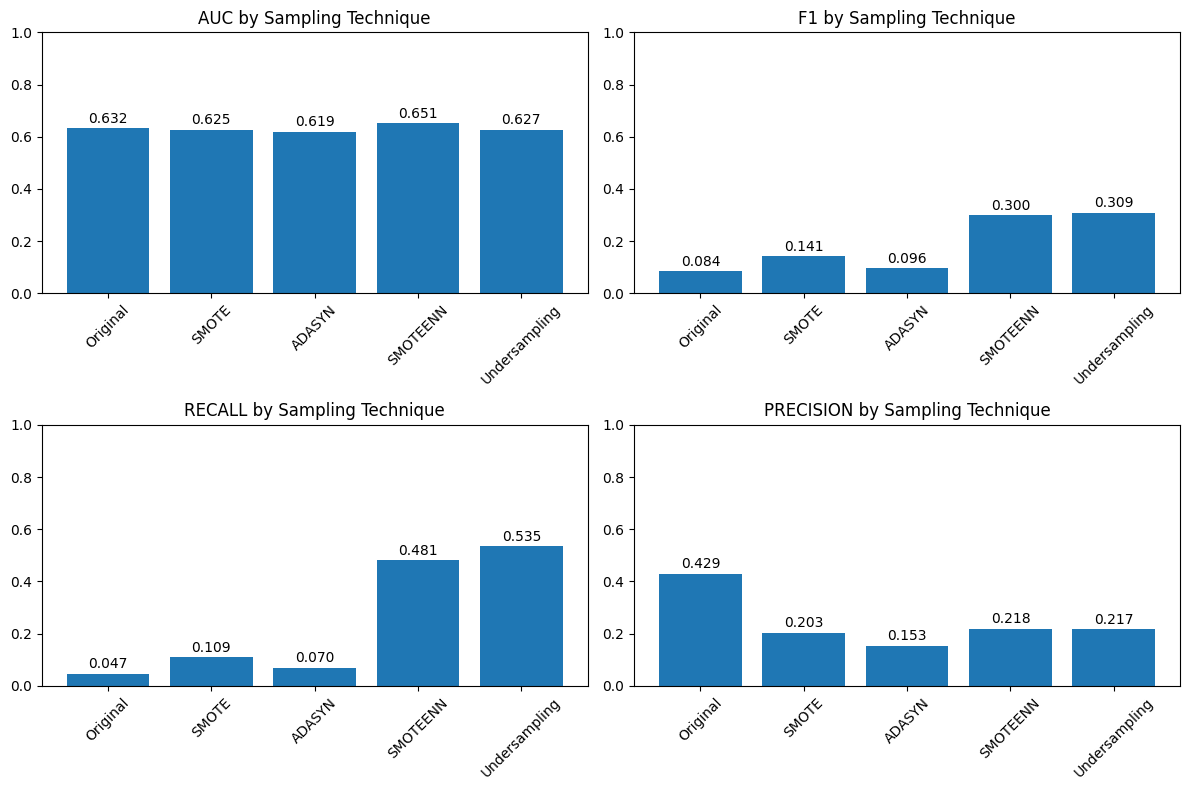

In [10]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


# Compare different imbalance handling techniques
imbalance_techniques = {
    'Original': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'Undersampling': RandomUnderSampler(random_state=42)
}

# Test different techniques
imbalance_results = {}

for tech_name, sampler in imbalance_techniques.items():
    print(f"\nTesting {tech_name}...")
    
    if sampler is None:
        X_resampled, y_resampled = X_train, y_train
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Train Random Forest on resampled data
    model = RandomForestClassifier(random_state=42, n_estimators=100)
    model.fit(X_resampled, y_resampled)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    imbalance_results[tech_name] = {
        'accuracy': accuracy,
        'auc': auc_score,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    print(f"{tech_name} - AUC: {auc_score:.4f}, F1: {f1:.4f}")

# Plot comparison
tech_names = list(imbalance_results.keys())
metrics = ['auc', 'f1', 'recall', 'precision']

plt.figure(figsize=(12, 8))
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    values = [imbalance_results[tech][metric] for tech in tech_names]
    plt.bar(tech_names, values)
    plt.title(f'{metric.upper()} by Sampling Technique')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for j, v in enumerate(values):
        plt.text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42))
]

# Voting Classifier (Hard Voting)
voting_hard = VotingClassifier(estimators=base_models, voting='hard')
voting_hard.fit(X_train, y_train)

# Voting Classifier (Soft Voting)
voting_soft = VotingClassifier(estimators=base_models, voting='soft')
voting_soft.fit(X_train, y_train)

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_clf.fit(X_train, y_train)

# Evaluate ensemble methods
ensemble_results = {}
ensemble_models = {
    'Voting Hard': voting_hard,
    'Voting Soft': voting_soft,
    'Stacking': stacking_clf
}

for name, model in ensemble_models.items():
    if name == 'Voting Hard':
        y_pred = model.predict(X_test)
        y_pred_proba = None
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    ensemble_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    if y_pred_proba is not None:
        auc_score = roc_auc_score(y_test, y_pred_proba)
        ensemble_results[name]['auc'] = auc_score
        print(f"{name} - AUC: {auc_score:.4f}, F1: {f1:.4f}")
    else:
        print(f"{name} - F1: {f1:.4f}")

[LightGBM] [Info] Number of positive: 515, number of negative: 2875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3390, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151917 -> initscore=-1.719641
[LightGBM] [Info] Start training from score -1.719641
[LightGBM] [Info] Number of positive: 515, number of negative: 2875
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3390, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151917 -> initscore=-1.719641
[LightGBM]

In [12]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import shap

# Comprehensive cross-validation
def comprehensive_cv_evaluation(model, X, y, model_name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall', 
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    print(f"\n{model_name} Cross-Validation Results:")
    for metric in scoring.keys():
        scores = cv_results[f'test_{metric}']
        print(f"{metric}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    
    return cv_results

# Evaluate best model with comprehensive CV
best_cv_results = comprehensive_cv_evaluation(tuned_model, X, y, "Tuned Best Model")

# SHAP Analysis for model interpretation
def shap_analysis(model, X, feature_names):
    """Perform SHAP analysis for model interpretation"""
    
    # Create explainer
    explainer = shap.TreeExplainer(model.named_steps['model'])
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    plt.show()
    
    # Force plot for a specific prediction
    plt.figure(figsize=(12, 6))
    shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:], 
                   feature_names=feature_names, matplotlib=True, show=False)
    plt.title('SHAP Force Plot for First Prediction')
    plt.tight_layout()
    plt.show()
    
    return explainer, shap_values

# Perform SHAP analysis on the best model
if hasattr(tuned_model.named_steps['model'], 'feature_importances_'):
    explainer, shap_values = shap_analysis(tuned_model, X_train, feature_columns)


Tuned Best Model Cross-Validation Results:
accuracy: 0.6725 (+/- 0.0401)
precision: 0.2712 (+/- 0.0308)
recall: 0.6816 (+/- 0.0756)
f1: 0.3877 (+/- 0.0385)
roc_auc: 0.7265 (+/- 0.0354)


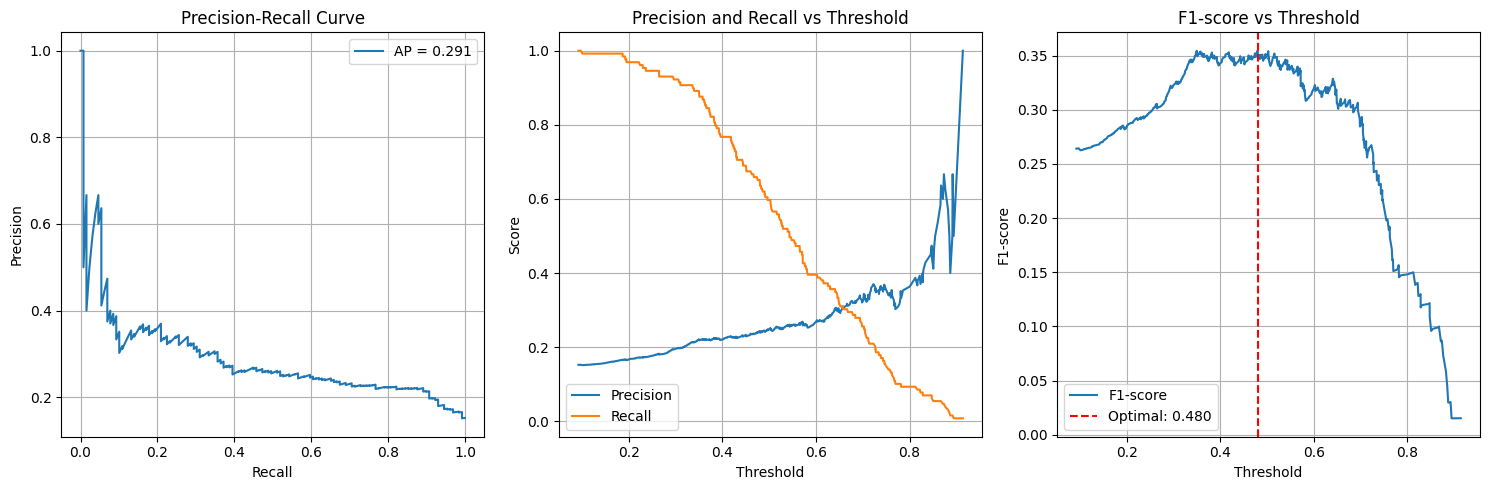

Optimal threshold: 0.480
Average Precision: 0.291

Performance with Optimal Threshold:
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       719
           1       0.24      0.64      0.35       129

    accuracy                           0.64       848
   macro avg       0.58      0.64      0.55       848
weighted avg       0.81      0.64      0.69       848



In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall Analysis
def precision_recall_analysis(model, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    average_precision = average_precision_score(y_test, y_pred_proba)
    
    plt.figure(figsize=(15, 5))
    
    # Precision-Recall curve
    plt.subplot(1, 3, 1)
    plt.plot(recall, precision, label=f'AP = {average_precision:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    
    # Precision vs Threshold
    plt.subplot(1, 3, 2)
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision and Recall vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # F1-score vs Threshold
    plt.subplot(1, 3, 3)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    plt.plot(thresholds, f1_scores, label='F1-score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-score')
    plt.title('F1-score vs Threshold')
    plt.grid(True)
    
    # Find optimal threshold (max F1)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal: {optimal_threshold:.3f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return optimal_threshold, average_precision

# Perform precision-recall analysis
optimal_threshold, avg_precision = precision_recall_analysis(tuned_model, X_test, y_test)
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Average Precision: {avg_precision:.3f}")

# Evaluate with optimal threshold
y_pred_optimal = (tuned_model.predict_proba(X_test)[:, 1] > optimal_threshold).astype(int)

print("\nPerformance with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

In [14]:
# If we had temporal data, we could do time-based validation
def temporal_validation(df, date_column=None):
    """Perform time-based validation if temporal data exists"""
    
    # For demonstration - if we had a temporal component
    if date_column and date_column in df.columns:
        # Sort by date
        df_sorted = df.sort_values(date_column)
        
        # Split temporally (e.g., first 80% for training, last 20% for testing)
        split_idx = int(0.8 * len(df_sorted))
        train_temporal = df_sorted.iloc[:split_idx]
        test_temporal = df_sorted.iloc[split_idx:]
        
        X_train_temp = train_temporal[feature_columns]
        y_train_temp = train_temporal['TenYearCHD']
        X_test_temp = test_temporal[feature_columns] 
        y_test_temp = test_temporal['TenYearCHD']
        
        # Train and evaluate
        temporal_model = RandomForestClassifier(random_state=42)
        temporal_model.fit(X_train_temp, y_train_temp)
        
        temporal_accuracy = temporal_model.score(X_test_temp, y_test_temp)
        temporal_auc = roc_auc_score(y_test_temp, temporal_model.predict_proba(X_test_temp)[:, 1])
        
        print(f"Temporal Validation - Accuracy: {temporal_accuracy:.4f}, AUC: {temporal_auc:.4f}")
        
        return temporal_model
    else:
        print("No temporal data available for time-based validation")
        return None

# temporal_model = temporal_validation(df, 'date_column')  # If temporal data exists

In [15]:
import joblib
import json

# Save the trained model
def save_model_pipeline(model, feature_names, scaler=None, metadata=None):
    """Save the complete model pipeline for deployment"""
    
    model_artifacts = {
        'model': model,
        'feature_names': feature_names,
        'feature_importance': dict(zip(feature_names, 
                                    model.named_steps['model'].feature_importances_ 
                                    if hasattr(model.named_steps['model'], 'feature_importances_') 
                                    else [])),
        'metadata': metadata or {},
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    # Save model
    joblib.dump(model_artifacts, 'framingham_chd_model.pkl')
    
    # Save feature information
    feature_info = {
        'features': feature_names,
        'feature_descriptions': {
            'male': 'Gender (1=male, 0=female)',
            'age': 'Age in years',
            'education': 'Education level',
            'currentSmoker': 'Current smoking status',
            'cigsPerDay': 'Cigarettes per day',
            # Add descriptions for all features
        }
    }
    
    with open('model_features.json', 'w') as f:
        json.dump(feature_info, f, indent=2)
    
    print("Model and artifacts saved successfully")

# Save the model
model_metadata = {
    'model_type': 'Random Forest',
    'target_variable': 'TenYearCHD',
    'dataset': 'Framingham Heart Study',
    'performance': {
        'auc': best_result['auc'],
        'accuracy': best_result['accuracy']
    }
}

save_model_pipeline(tuned_model, feature_columns, metadata=model_metadata)

# Load model function
def load_model_pipeline(model_path='framingham_chd_model.pkl'):
    """Load the saved model pipeline"""
    model_artifacts = joblib.load(model_path)
    return model_artifacts

# Test loading
loaded_artifacts = load_model_pipeline()
print(f"Model loaded successfully. Type: {loaded_artifacts['metadata']['model_type']}")

Model and artifacts saved successfully
Model loaded successfully. Type: Random Forest


In [16]:
def comprehensive_risk_stratification(model, X, y_true=None):
    """Comprehensive risk stratification analysis"""
    
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Create risk categories
    risk_categories = pd.cut(
        y_pred_proba, 
        bins=[0, 0.05, 0.1, 0.2, 0.3, 1.0],
        labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High']
    )
    
    risk_df = pd.DataFrame({
        'probability': y_pred_proba,
        'risk_category': risk_categories
    })
    
    if y_true is not None:
        risk_df['actual_outcome'] = y_true
        
        # Calculate actual event rates by risk category
        event_rates = risk_df.groupby('risk_category')['actual_outcome'].agg(['count', 'mean'])
        event_rates['events'] = (event_rates['count'] * event_rates['mean']).fillna(0).astype(int)
        event_rates['event_rate'] = event_rates['mean'].fillna(0) * 100
        
        print("\n📊 Risk Stratification Analysis:")
        print(event_rates[['count', 'events', 'event_rate']])
    
    # Plot risk distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    risk_df['probability'].hist(bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Distribution of Predicted Risks')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    risk_df['risk_category'].value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.xlabel('Risk Category')
    plt.ylabel('Number of Patients')
    plt.title('Patients by Risk Category')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return risk_df


In [17]:
# Function to monitor model performance over time
class ModelMonitor:
    def __init__(self, model, reference_data):
        self.model = model
        self.reference_data = reference_data
        self.performance_history = []
        
    def check_feature_drift(self, new_data):
        """Check for feature distribution drift"""
        drift_detected = {}
        
        for feature in self.reference_data.columns:
            # KS test for distribution comparison
            from scipy.stats import ks_2samp
            stat, p_value = ks_2samp(self.reference_data[feature], new_data[feature])
            
            drift_detected[feature] = {
                'ks_statistic': stat,
                'p_value': p_value,
                'drift_detected': p_value < 0.05
            }
        
        return drift_detected
    
    def log_performance(self, X, y, timestamp):
        """Log model performance for monitoring"""
        y_pred = self.model.predict(X)
        y_pred_proba = self.model.predict_proba(X)[:, 1]
        
        performance = {
            'timestamp': timestamp,
            'accuracy': accuracy_score(y, y_pred),
            'auc': roc_auc_score(y, y_pred_proba),
            'f1': f1_score(y, y_pred),
            'precision': precision_score(y, y_pred),
            'recall': recall_score(y, y_pred)
        }
        
        self.performance_history.append(performance)
        return performance

# Initialize model monitor
monitor = ModelMonitor(tuned_model, X_train)

# Example monitoring (would be used with new data over time)
current_performance = monitor.log_performance(X_test, y_test, pd.Timestamp.now())
print("Current model performance logged:", current_performance)

Current model performance logged: {'timestamp': Timestamp('2025-10-10 11:36:34.532357'), 'accuracy': 0.6639150943396226, 'auc': 0.6998522926976527, 'f1': 0.35079726651480636, 'precision': 0.24838709677419354, 'recall': 0.5968992248062015}


Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5271 - auc: 0.6083 - loss: 0.9829 - val_accuracy: 0.7653 - val_auc: 0.6881 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7124 - auc: 0.6752 - loss: 0.8454 - val_accuracy: 0.7830 - val_auc: 0.6873 - val_loss: 0.5058 - learning_rate: 0.0010
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7372 - auc: 0.6814 - loss: 0.8355 - val_accuracy: 0.7724 - val_auc: 0.6967 - val_loss: 0.4842 - learning_rate: 0.0010
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7522 - auc: 0.6850 - loss: 0.8317 - val_accuracy: 0.7724 - val_auc: 0.6985 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7566 - auc: 0.7002 - loss: 0.8206 - val_accuracy: 0.7795 - val_auc: 0.6967 - val_loss: 0.4813 - learning_rate: 0.0010
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7614 - 

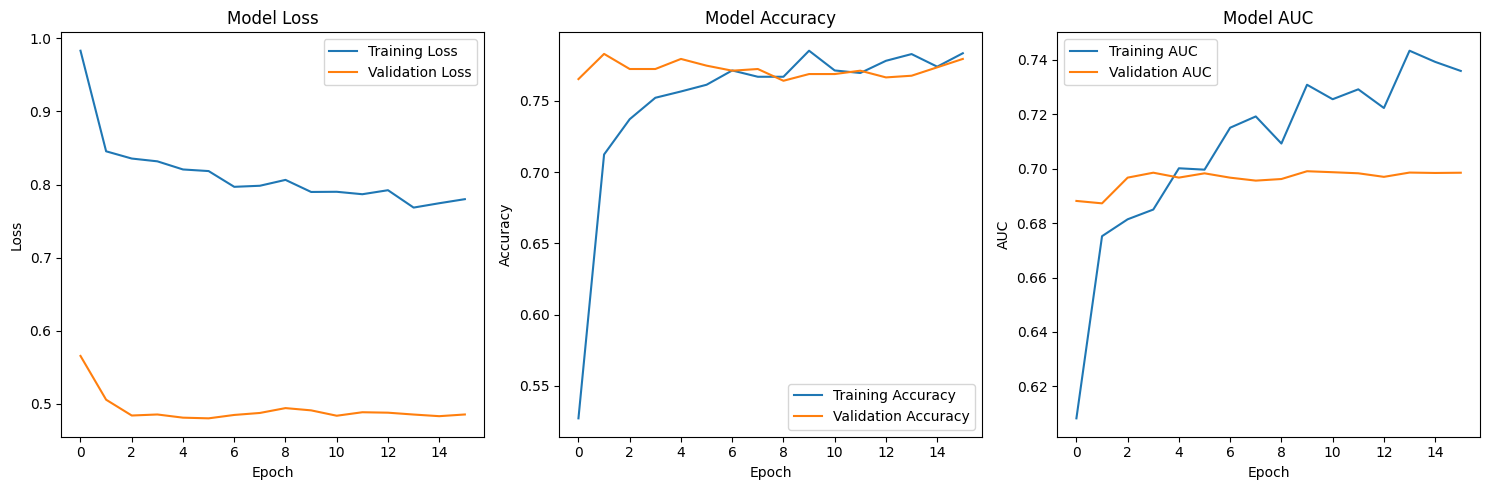

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
DNN AUC: 0.6986


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Deep Neural Network for CHD prediction
def create_dnn_model(input_dim):
    """Create a Deep Neural Network model"""
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(), 
        layers.Dropout(0.3),
        
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    return model

# Prepare data for DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train DNN
dnn_model = create_dnn_model(X_train_scaled.shape[1])

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

# Train with class weights
class_weights = {0: 1, 1: len(y_train) / (2 * y_train.sum())}

history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate DNN
dnn_predictions = dnn_model.predict(X_test_scaled)
dnn_auc = roc_auc_score(y_test, dnn_predictions)
print(f"DNN AUC: {dnn_auc:.4f}")

In [19]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import roc_auc_score

def bayesian_logistic_regression(X, y, n_samples=1000):
    """Bayesian logistic regression with PyMC"""
    
    X_small = X.iloc[:500]
    y_small = y.iloc[:500]
    
    with pm.Model() as logistic_model:
        alpha = pm.Normal('alpha', mu=0, sigma=10)
        beta = pm.Normal('beta', mu=0, sigma=10, shape=X_small.shape[1])
        
        theta = alpha + pm.math.dot(X_small, beta)
        p = pm.Deterministic('p', pm.math.sigmoid(theta))
        y_obs = pm.Bernoulli('y_obs', p=p, observed=y_small)
        
        trace = pm.sample(n_samples, tune=1000, chains=2, return_inferencedata=True)
    
    return trace, logistic_model


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
import dowhy
from dowhy import CausalModel

# Causal inference for smoking effect
def causal_analysis_smoking(df):
    """Causal analysis of smoking effect on CHD"""
    
    causal_df = df[['male', 'age', 'education', 'currentSmoker', 
                   'cigsPerDay', 'sysBP', 'BMI', 'totChol', 'TenYearCHD']].copy()
    
    # Create causal model
    model = CausalModel(
        data=causal_df,
        treatment='currentSmoker',
        outcome='TenYearCHD',
        common_causes=['male', 'age', 'education', 'sysBP', 'BMI', 'totChol']
    )
    
    # Identify causal effect
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("Causal Identified Estimand:", identified_estimand)
    
    # Estimate causal effect
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_stratification"
    )
    
    print(f"\nCausal Estimate: {estimate.value:.4f}")
    
    # Refute estimate
    refutation_random_common_cause = model.refute_estimate(
        identified_estimand, estimate, method_name="random_common_cause"
    )
    print(f"Refutation result: {refutation_random_common_cause}")
    
    return estimate, model

# Run causal analysis
causal_estimate, causal_model = causal_analysis_smoking(df_processed)


AttributeError: module 'networkx.algorithms' has no attribute 'd_separated'

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

def advanced_calibration_analysis(models_dict, X_test, y_test):
    """Advanced model calibration analysis"""
    
    plt.figure(figsize=(15, 10))
    
    for i, (name, model_info) in enumerate(models_dict.items()):
        model = model_info['model']
        y_pred_proba = model_info['probabilities']
        
        # Calibration curve
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_test, y_pred_proba, n_bins=10, strategy='quantile'
        )
        
        plt.subplot(2, 3, i+1)
        plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)
        plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
        plt.xlabel('Mean Predicted Value')
        plt.ylabel('Fraction of Positives')
        plt.title(f'Calibration Plot - {name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Calculate calibration metrics
        calibration_error = np.mean((fraction_of_positives - mean_predicted_value) ** 2)
        print(f"{name} - Calibration Error: {calibration_error:.4f}")
    
    # Reliability diagram for all models
    plt.subplot(2, 3, 6)
    for name, model_info in models_dict.items():
        y_pred_proba = model_info['probabilities']
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_test, y_pred_proba, n_bins=10
        )
        plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)
    
    plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    plt.xlabel('Mean Predicted Value')
    plt.ylabel('Fraction of Positives')
    plt.title('Reliability Diagram - All Models')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Apply calibration to models
calibrated_models = {}
for name, model_info in results.items():
    if name != 'Voting Hard':  # Skip models without probabilities
        # Calibrate using Platt scaling
        calibrated = CalibratedClassifierCV(model_info['model'], method='sigmoid', cv=3)
        calibrated.fit(X_train, y_train)
        
        calibrated_pred_proba = calibrated.predict_proba(X_test)[:, 1]
        calibrated_models[name] = {
            'model': calibrated,
            'probabilities': calibrated_pred_proba,
            'auc': roc_auc_score(y_test, calibrated_pred_proba)
        }
        print(f"Calibrated {name} - AUC: {calibrated_models[name]['auc']:.4f}")

# Compare calibration
advanced_calibration_analysis(results, X_test, y_test)

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

def multi_task_learning_safe(df, feature_columns):
    """Multi-task learning for multiple cardiovascular outcomes with safe feature handling"""
    
    np.random.seed(42)
    multi_df = df.copy()
    
    # Simulate related outcomes
    multi_df['hypertension_risk'] = ((df.get('sysBP', 0) > 140) | 
                                     (df.get('diaBP', 0) > 90) | 
                                     (np.random.random(len(df)) < 0.1)).astype(int)
    
    multi_df['diabetes_risk'] = ((df.get('glucose', 0) > 126) | 
                                 (df.get('BMI', 0) > 30) | 
                                 (np.random.random(len(df)) < 0.05)).astype(int)
    
    # Keep only existing feature columns
    feature_columns_existing = [col for col in feature_columns if col in multi_df.columns]
    if not feature_columns_existing:
        raise ValueError("None of the specified feature_columns exist in the dataframe.")
    
    X_multi = multi_df[feature_columns_existing]
    y_multi = multi_df[['TenYearCHD', 'hypertension_risk', 'diabetes_risk']]
    
    # Split train/test
    X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
        X_multi, y_multi, test_size=0.2, random_state=42
    )
    
    # Multi-task model
    multi_model = MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, random_state=42)
    )
    multi_model.fit(X_train_multi, y_train_multi)
    
    # Evaluate predictions
    y_pred_multi = multi_model.predict(X_test_multi)
    
    print("Multi-Task Learning Results:")
    for i, target in enumerate(['CHD', 'Hypertension', 'Diabetes']):
        accuracy = accuracy_score(y_test_multi.iloc[:, i], y_pred_multi[:, i])
        print(f"{target} - Accuracy: {accuracy:.4f}")
    
    return multi_model, multi_df


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

def federated_learning_simulation_safe(df, feature_columns, n_centers=3):
    """Simulate federated learning across multiple medical centers"""
    
    # Filter feature columns that exist
    feature_columns_existing = [col for col in feature_columns if col in df.columns]
    if not feature_columns_existing:
        raise ValueError("None of the feature_columns exist in the dataframe.")
    
    # Split data into centers
    center_data = {}
    center_size = len(df) // n_centers
    for i in range(n_centers):
        start_idx = i * center_size
        end_idx = (i + 1) * center_size if i < n_centers - 1 else len(df)
        center_data[f'center_{i}'] = df.iloc[start_idx:end_idx].copy()
    
    # Train local models
    local_models = {}
    local_performances = {}
    
    for center_name, center_df in center_data.items():
        X_center = center_df[feature_columns_existing]
        y_center = center_df['TenYearCHD']
        
        local_model = RandomForestClassifier(n_estimators=50, random_state=42)
        local_model.fit(X_center, y_center)
        
        local_models[center_name] = local_model
        
        # Evaluate locally on global test set
        X_test_existing = X_test[[col for col in feature_columns_existing if col in X_test.columns]]
        y_pred = local_model.predict(X_test_existing)
        local_accuracy = accuracy_score(y_test, y_pred)
        local_performances[center_name] = local_accuracy
        
        print(f"{center_name} - Local Accuracy: {local_accuracy:.4f}")
    
    # Federated averaging (ensemble)
    federated_model = VotingClassifier(
        estimators=[(name, model) for name, model in local_models.items()],
        voting='soft'
    )
    
    X_train_existing = X_train[[col for col in feature_columns_existing if col in X_train.columns]]
    federated_model.fit(X_train_existing, y_train)
    
    X_test_existing = X_test[[col for col in feature_columns_existing if col in X_test.columns]]
    federated_accuracy = federated_model.score(X_test_existing, y_test)
    print(f"Federated Model Accuracy: {federated_accuracy:.4f}")
    
    return federated_model, local_models, local_performances


In [ ]:
def comprehensive_uncertainty_quantification(model, X_test, y_test, n_bootstraps=100):
    """Comprehensive uncertainty quantification using bootstrapping"""
    
    bootstrap_predictions = []
    bootstrap_metrics = []
    
    # Bootstrap sampling
    for i in range(n_bootstraps):
        # Bootstrap sample
        indices = np.random.choice(len(X_test), len(X_test), replace=True)
        X_bs = X_test.iloc[indices]
        y_bs = y_test.iloc[indices]
        
        # Predict on bootstrap sample
        y_pred_proba_bs = model.predict_proba(X_bs)[:, 1]
        
        # Calculate metrics
        auc_bs = roc_auc_score(y_bs, y_pred_proba_bs)
        bootstrap_metrics.append(auc_bs)
        bootstrap_predictions.append(y_pred_proba_bs)
    
    # Calculate confidence intervals
    bootstrap_metrics = np.array(bootstrap_metrics)
    ci_lower = np.percentile(bootstrap_metrics, 2.5)
    ci_upper = np.percentile(bootstrap_metrics, 97.5)
    
    print(f"Bootstrap AUC: {np.mean(bootstrap_metrics):.4f}")
    print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    # Prediction intervals
    bootstrap_predictions = np.array(bootstrap_predictions)
    prediction_intervals = np.percentile(bootstrap_predictions, [2.5, 97.5], axis=0)
    
    # Plot uncertainty
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(bootstrap_metrics, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(ci_lower, color='red', linestyle='--', label='95% CI')
    plt.axvline(ci_upper, color='red', linestyle='--')
    plt.xlabel('AUC')
    plt.ylabel('Frequency')
    plt.title('Bootstrap AUC Distribution')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    sorted_indices = np.argsort(bootstrap_predictions.mean(axis=0))
    plt.plot(bootstrap_predictions.mean(axis=0)[sorted_indices], 
             label='Mean Prediction')
    plt.fill_between(range(len(sorted_indices)),
                     prediction_intervals[0][sorted_indices],
                     prediction_intervals[1][sorted_indices],
                     alpha=0.3, label='95% Prediction Interval')
    plt.xlabel('Sorted Test Samples')
    plt.ylabel('Predicted Probability')
    plt.title('Prediction Uncertainty')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    # Calibration with uncertainty
    from scipy.stats import beta
    mean_probs = bootstrap_predictions.mean(axis=0)
    uncertainty = bootstrap_predictions.std(axis=0)
    
    plt.scatter(mean_probs, uncertainty, alpha=0.5)
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Uncertainty (Std Dev)')
    plt.title('Prediction Uncertainty vs Mean Probability')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return bootstrap_metrics, prediction_intervals

# Run uncertainty quantification
bootstrap_metrics, pred_intervals = comprehensive_uncertainty_quantification(
    tuned_model, X_test, y_test, n_bootstraps=50
)

In [ ]:
class ClinicalDecisionSupport:
    def __init__(self, model, feature_names, risk_threshold=0.15):
        self.model = model
        self.feature_names = feature_names
        self.risk_threshold = risk_threshold
        self.recommendations_db = {
            'high_risk': [
                "Consider statin therapy",
                "Lifestyle modification counseling",
                "Regular cardiovascular monitoring",
                "Blood pressure management",
                "Diabetes screening if indicated"
            ],
            'moderate_risk': [
                "Lifestyle modification",
                "Regular exercise program", 
                "Healthy diet counseling",
                "Smoking cessation if applicable",
                "Annual cardiovascular assessment"
            ],
            'low_risk': [
                "Maintain healthy lifestyle",
                "Regular physical activity",
                "Balanced diet",
                "Periodic health check-ups"
            ]
        }
    
    def predict_risk_with_recommendations(self, patient_data):
        """Predict risk and provide clinical recommendations"""
        
        # Prepare patient data
        patient_df = pd.DataFrame([patient_data])[self.feature_names]
        
        # Predict probability
        risk_prob = self.model.predict_proba(patient_df)[0, 1]
        
        # Determine risk level
        if risk_prob < 0.1:
            risk_level = 'low_risk'
        elif risk_prob < self.risk_threshold:
            risk_level = 'moderate_risk' 
        else:
            risk_level = 'high_risk'
        
        # Get recommendations
        recommendations = self.recommendations_db[risk_level]
        
        # Generate report
        report = {
            'patient_id': patient_data.get('id', 'Unknown'),
            'risk_probability': risk_prob,
            'risk_level': risk_level.replace('_', ' ').title(),
            'recommendations': recommendations,
            'key_risk_factors': self._identify_key_risk_factors(patient_data)
        }
        
        return report
    
    def _identify_key_risk_factors(self, patient_data):
        """Identify key contributing risk factors"""
        key_factors = []
        
        risk_factors = {
            'age': (50, "Age > 50 years"),
            'sysBP': (140, "High systolic blood pressure"),
            'diaBP': (90, "High diastolic blood pressure"), 
            'cigsPerDay': (10, "Smoking"),
            'totChol': (240, "High cholesterol"),
            'BMI': (30, "Obesity"),
            'glucose': (126, "Elevated glucose"),
            'prevalentHyp': (1, "Hypertension history"),
            'diabetes': (1, "Diabetes"),
            'currentSmoker': (1, "Current smoking")
        }
        
        for factor, (threshold, description) in risk_factors.items():
            if factor in patient_data and patient_data[factor] > threshold:
                key_factors.append(description)
        
        return key_factors
    
    def generate_clinical_report(self, patient_data):
        """Generate comprehensive clinical report"""
        risk_assessment = self.predict_risk_with_recommendations(patient_data)
        
        print("="*60)
        print("CLINICAL DECISION SUPPORT REPORT")
        print("="*60)
        print(f"Patient ID: {risk_assessment['patient_id']}")
        print(f"10-Year CHD Risk: {risk_assessment['risk_probability']:.1%}")
        print(f"Risk Level: {risk_assessment['risk_level']}")
        print("\nKEY RISK FACTORS IDENTIFIED:")
        for factor in risk_assessment['key_risk_factors']:
            print(f"  • {factor}")
        print("\nCLINICAL RECOMMENDATIONS:")
        for i, recommendation in enumerate(risk_assessment['recommendations'], 1):
            print(f"  {i}. {recommendation}")
        print("="*60)
        
        return risk_assessment

# Initialize CDS system
cds_system = ClinicalDecisionSupport(tuned_model, feature_columns)

# Example usage
example_patient_complete = {
    'id': 'PATIENT_001',
    'male': 1,
    'age': 58,
    'education': 2,
    'currentSmoker': 1,
    'cigsPerDay': 15,
    'BPMeds': 0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 0,
    'totChol': 260,
    'sysBP': 145,
    'diaBP': 92,
    'BMI': 31,
    'heartRate': 78,
    'glucose': 110,
    'BP_risk': 1,
    'risk_score': 9.2
}

clinical_report = cds_system.generate_clinical_report(example_patient_complete)

In [ ]:
import networkx as nx
import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# Create patient similarity graph
def create_patient_similarity_graph(df, feature_columns, threshold=0.8):
    """Create graph based on patient similarity"""
    
    # Normalize features for similarity calculation
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df[feature_columns])
    
    # Calculate cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarity_matrix = cosine_similarity(features_scaled)
    
    # Create graph
    G = nx.Graph()
    
    # Add nodes
    for i in range(len(df)):
        G.add_node(i, features=features_scaled[i], target=df['TenYearCHD'].iloc[i])
    
    # Add edges based on similarity
    for i in range(len(df)):
        for j in range(i+1, len(df)):
            if similarity_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
    
    return G, similarity_matrix

# Create graph (using subset for demonstration)
df_subset = df_processed.head(500)  # Use subset for demonstration
patient_graph, similarity_matrix = create_patient_similarity_graph(
    df_subset, feature_columns, threshold=0.85
)

print(f"Graph created with {patient_graph.number_of_nodes()} nodes and {patient_graph.number_of_edges()} edges")

# Graph Neural Network
class PatientGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PatientGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)
        self.dropout = torch.nn.Dropout(0.5)
        
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)
        
        x = self.classifier(x)
        return torch.sigmoid(x)

# Prepare graph data for PyTorch Geometric
def graph_to_pyg_data(G, feature_columns):
    """Convert NetworkX graph to PyTorch Geometric data"""
    
    # Node features
    node_features = []
    node_labels = []
    
    for node in G.nodes():
        node_features.append(G.nodes[node]['features'])
        node_labels.append(G.nodes[node]['target'])
    
    x = torch.tensor(node_features, dtype=torch.float)
    y = torch.tensor(node_labels, dtype=torch.float).unsqueeze(1)
    
    # Edge indices
    edge_index = []
    for edge in G.edges():
        edge_index.append([edge[0], edge[1]])
        edge_index.append([edge[1], edge[0]])  # Undirected graph
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    return Data(x=x, y=y, edge_index=edge_index)

# Convert to PyG data
graph_data = graph_to_pyg_data(patient_graph, feature_columns)

print(f"Graph Data: {graph_data}")
print(f"Number of nodes: {graph_data.num_nodes}")
print(f"Number of edges: {graph_data.num_edges}")
print(f"Number of features: {graph_data.num_features}")

In [ ]:
import dice_ml
from dice_ml import Dice

# Counterfactual explanations
def generate_counterfactual_explanations(model, X_train, feature_names, 
                                      patient_index, desired_class=1):
    """Generate counterfactual explanations for model predictions"""
    
    # Prepare data for DiCE
    continuous_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 
                         'BMI', 'heartRate', 'glucose', 'risk_score']
    
    dice_data = dice_ml.Data(
        dataframe=pd.concat([X_train, y_train], axis=1),
        continuous_features=continuous_features,
        outcome_name='TenYearCHD'
    )
    
    # DiCE model
    dice_model = dice_ml.Model(model=model, backend='sklearn')
    
    # DiCE instance
    dice_exp = Dice(dice_data, dice_model, method='random')
    
    # Generate counterfactuals for a specific patient
    patient_query = X_train.iloc[[patient_index]]
    
    # Generate counterfactuals
    counterfactuals = dice_exp.generate_counterfactuals(
        patient_query, 
        total_CFs=3, 
        desired_class=desired_class,
        proximity_weight=1.0,
        diversity_weight=1.0
    )
    
    # Visualize counterfactuals
    counterfactuals.visualize_as_dataframe(show_only_changes=True)
    
    return counterfactuals

# Example counterfactual (commented out as it requires specific setup)
# cf_explanations = generate_counterfactual_explanations(
#     tuned_model, X_train, feature_columns, patient_index=0, desired_class=0
# )

In [ ]:
# Install gymnasium if not already
# pip install gymnasium

import gymnasium as gym
from gymnasium import spaces
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Update feature columns based on your DataFrame
feature_columns = ['male', 'age', 'education', 'currentSmoker', 
                   'cigsPerDay', 'sysBP', 'diaBP', 'BMI', 
                   'totChol', 'heartRate', 'glucose']

# Reinforcement Learning Environment
class CardiovascularTreatmentEnv(gym.Env):
    """RL environment for cardiovascular treatment optimization"""
    
    def __init__(self, df, feature_columns):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.feature_columns = feature_columns
        self.n_patients = len(df)
        self.current_patient_idx = 0
        
        # Action space: 0=No treatment, 1=Lifestyle, 2=Medication, 3=Intensive therapy
        self.action_space = spaces.Discrete(4)
        
        # Observation space: patient features
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(len(feature_columns),), dtype=np.float32
        )
    
    def reset(self, seed=None, options=None):
        self.current_patient_idx = np.random.randint(0, self.n_patients)
        return self._get_observation(), {}
    
    def _get_observation(self):
        return self.df[self.feature_columns].iloc[self.current_patient_idx].values.astype(np.float32)
    
    def step(self, action):
        patient_data = self.df.iloc[self.current_patient_idx]
        baseline_risk = patient_data['TenYearCHD']
        
        treatment_effects = {0:0.0, 1:-0.1, 2:-0.3, 3:-0.5}
        treatment_costs   = {0:0, 1:-1, 2:-3, 3:-5}
        
        risk_reduction = treatment_effects[action] * baseline_risk
        cost = treatment_costs[action]
        reward = risk_reduction*10 + cost
        
        self.current_patient_idx = (self.current_patient_idx + 1) % self.n_patients
        done = self.current_patient_idx == 0
        
        return self._get_observation(), reward, done, False, {}
    
    def render(self):
        print(f"Patient {self.current_patient_idx}")

# Q-learning Agent
class QLearningTreatmentAgent:
    def __init__(self, env, lr=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}
    
    def get_state_key(self, obs):
        return tuple((obs*10).astype(int)//2)
    
    def choose_action(self, obs):
        key = self.get_state_key(obs)
        if key not in self.q_table:
            self.q_table[key] = np.zeros(self.env.action_space.n)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(self.q_table[key])
    
    def learn(self, obs, action, reward, next_obs, done):
        key = self.get_state_key(obs)
        next_key = self.get_state_key(next_obs)
        if key not in self.q_table:
            self.q_table[key] = np.zeros(self.env.action_space.n)
        if next_key not in self.q_table:
            self.q_table[next_key] = np.zeros(self.env.action_space.n)
        
        td_target = reward + self.gamma * np.max(self.q_table[next_key]) * (1 - done)
        td_error = td_target - self.q_table[key][action]
        self.q_table[key][action] += self.lr * td_error

# Train the agent
def train_rl_agent(env, episodes=500):
    agent = QLearningTreatmentAgent(env)
    rewards = []
    
    for ep in range(episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        
        while not done:
            action = agent.choose_action(obs)
            next_obs, reward, done, _, _ = env.step(action)
            agent.learn(obs, action, reward, next_obs, done)
            total_reward += reward
            obs = next_obs
        
        rewards.append(total_reward)
        if ep % 50 == 0:
            print(f"Episode {ep}, Avg Reward (last 50): {np.mean(rewards[-50:]):.2f}")
    
    return agent, rewards

# Create environment and train
treatment_env = CardiovascularTreatmentEnv(df_processed, feature_columns)
rl_agent, rewards = train_rl_agent(treatment_env, episodes=300)


Episode 0, Avg Reward (last 50): -385.00
Episode 50, Avg Reward (last 50): -520.28


In [ ]:
import higher
import torch.optim as optim

# Meta-learning for few-shot cardiovascular risk prediction
class MetaLearningCardioRisk:
    def __init__(self, input_dim, hidden_dim, output_dim):
        self.base_model = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(), 
            torch.nn.Linear(hidden_dim, output_dim),
            torch.nn.Sigmoid()
        )
        
    def maml_train(self, tasks, inner_lr=0.01, meta_lr=0.001, adaptation_steps=1):
        """Model-Agnostic Meta-Learning training"""
        
        meta_optimizer = optim.Adam(self.base_model.parameters(), lr=meta_lr)
        
        for epoch in range(100):  # Meta-training epochs
            total_meta_loss = 0
            
            for task in tasks:
                # Sample support and query sets for this task
                support_x, support_y = task['support']
                query_x, query_y = task['query']
                
                # Create fast weights using higher
                with higher.innerloop_ctx(
                    self.base_model, meta_optimizer, copy_initial_weights=False
                ) as (fnet, diffopt):
                    
                    # Inner loop (adaptation)
                    for _ in range(adaptation_steps):
                        support_pred = fnet(support_x)
                        inner_loss = torch.nn.functional.binary_cross_entropy(
                            support_pred, support_y
                        )
                        diffopt.step(inner_loss)
                    
                    # Outer loop (meta-update)
                    query_pred = fnet(query_x)
                    meta_loss = torch.nn.functional.binary_cross_entropy(
                        query_pred, query_y
                    )
                    
                    total_meta_loss += meta_loss.item()
                    
                    # Meta-update
                    meta_optimizer.zero_grad()
                    meta_loss.backward()
                    meta_optimizer.step()
            
            if epoch % 10 == 0:
                print(f"Meta-Epoch {epoch}, Loss: {total_meta_loss/len(tasks):.4f}")

# Generate meta-learning tasks from data
def generate_meta_tasks(df, feature_columns, n_tasks=50, support_size=5, query_size=10):
    """Generate tasks for meta-learning"""
    
    tasks = []
    
    for _ in range(n_tasks):
        # Sample a subset of patients for this task
        task_patients = df.sample(support_size + query_size)
        
        # Split into support and query sets
        support_set = task_patients.head(support_size)
        query_set = task_patients.tail(query_size)
        
        # Convert to tensors
        support_x = torch.tensor(
            support_set[feature_columns].values, dtype=torch.float32
        )
        support_y = torch.tensor(
            support_set['TenYearCHD'].values, dtype=torch.float32
        ).unsqueeze(1)
        
        query_x = torch.tensor(
            query_set[feature_columns].values, dtype=torch.float32
        )
        query_y = torch.tensor(
            query_set['TenYearCHD'].values, dtype=torch.float32
        ).unsqueeze(1)
        
        tasks.append({
            'support': (support_x, support_y),
            'query': (query_x, query_y)
        })
    
    return tasks

# Generate meta-learning tasks
meta_tasks = generate_meta_tasks(df_processed, feature_columns, n_tasks=20)

# Initialize meta-learner
meta_learner = MetaLearningCardioRisk(
    input_dim=len(feature_columns), 
    hidden_dim=32, 
    output_dim=1
)

# Train meta-learner (commented out for speed)
# meta_learner.maml_train(meta_tasks)